# Ordinal Regression for activity data (Oct 2022 data)


In [1]:
import pathlib

import numpy as np
import pandas as pd

from scipy.stats import rankdata

import matplotlib.pyplot as plt
import seaborn as sns

import Bio
import Bio.Seq
import Bio.SeqIO

import utils

np.random.seed(10)

In [2]:
data_dir = pathlib.Path("../data/scratch/Oct22")
figs_dir = pathlib.Path("../data/misc")

In [3]:
seqs = pd.read_csv("../data/sequences_Oct22.tsv", sep="\t")
seqs

,ss_dna,dna_count,dna_dist,aa_dist,ss_aa,early_stop,seq_rank,parent,category
0,"G43T,T454C,T594A",20356,3,3,"A15S,F152L,N198K",False,1,1VH,H
1,A679G,18573,1,1,K227E,False,2,1VH,H
2,"C17G,A178G,G257A",17532,3,3,"P6R,S60G,G86D",False,3,1VH,H
3,*0*,11321,0,0,*0*,False,4,1VH,H
4,"C71T,A565G",29019,2,2,"A24V,N189D",False,1,1VH,P
...,...,...,...,...,...,...,...,...,...
1485,"T33C,A263T,A491T,G690A,C699G",187,5,2,"K88I,D164V",False,180,3VRL,N
1486,"T33C,G382T,C699G",185,3,1,G128C,False,181,3VRL,N
1487,"T33C,A200T,A444G,T551C,C699G",180,5,2,"H67L,I184T",False,182,3VRL,N
1488,"T33C,T656C,C699G,C713T",125,4,2,"I219T,T238I",False,184,3VRL,N


In [4]:
seqs_no_dups = seqs.drop_duplicates(["parent", "category", "ss_aa"], keep='first')
seqs_no_dups

,ss_dna,dna_count,dna_dist,aa_dist,ss_aa,early_stop,seq_rank,parent,category
0,"G43T,T454C,T594A",20356,3,3,"A15S,F152L,N198K",False,1,1VH,H
1,A679G,18573,1,1,K227E,False,2,1VH,H
2,"C17G,A178G,G257A",17532,3,3,"P6R,S60G,G86D",False,3,1VH,H
3,*0*,11321,0,0,*0*,False,4,1VH,H
4,"C71T,A565G",29019,2,2,"A24V,N189D",False,1,1VH,P
...,...,...,...,...,...,...,...,...,...
1485,"T33C,A263T,A491T,G690A,C699G",187,5,2,"K88I,D164V",False,180,3VRL,N
1486,"T33C,G382T,C699G",185,3,1,G128C,False,181,3VRL,N
1487,"T33C,A200T,A444G,T551C,C699G",180,5,2,"H67L,I184T",False,182,3VRL,N
1488,"T33C,T656C,C699G,C713T",125,4,2,"I219T,T238I",False,184,3VRL,N


In [5]:
# save just one sequence for the parents
parent_seqs = seqs_no_dups[seqs_no_dups.ss_aa == "*0*"].groupby("parent").head(1)
parent_seqs.category = "P"

In [6]:
# remove the parents from dataframe and add in the special parents dataframe
final_seqs = pd.concat([seqs_no_dups[seqs_no_dups.ss_aa != "*0*" ], parent_seqs])
final_seqs

,ss_dna,dna_count,dna_dist,aa_dist,ss_aa,early_stop,seq_rank,parent,category
0,"G43T,T454C,T594A",20356,3,3,"A15S,F152L,N198K",False,1,1VH,H
1,A679G,18573,1,1,K227E,False,2,1VH,H
2,"C17G,A178G,G257A",17532,3,3,"P6R,S60G,G86D",False,3,1VH,H
4,"C71T,A565G",29019,2,2,"A24V,N189D",False,1,1VH,P
6,"A328T,G774T",1200,2,2,"T110S,M258I",False,2,1VH,L
...,...,...,...,...,...,...,...,...,...
1488,"T33C,T656C,C699G,C713T",125,4,2,"I219T,T238I",False,184,3VRL,N
1489,"T33C,T123A,A263T,A491T,G690A,C699G",116,6,3,"D41E,K88I,D164V",False,185,3VRL,N
3,*0*,11321,0,0,*0*,False,4,1VH,P
457,*0*,6378,0,0,*0*,False,1,2L,P


## create one-hot encoding of ss_aa

In [7]:
class MutationEncoder:

    def __init__(self):
        self.sorted_positions = None
        self.lookupd = {}
        self.num_categories_pos = None
        self.category_start_pos = None
        self.N_one_hot = 0
        self.features = []
        
    
    def fit(self, mutation_list):
        all_mutations = [msplit for m in mutation_list for msplit in m.split(',')]
        all_mutations_pos = np.array([int(m[1:-1]) for m in all_mutations], dtype="int")
        all_mutations_char = np.array([m[-1] for m in all_mutations])
        all_mutations_wt = np.array([m[0] for m in all_mutations])
        
        self.sorted_positions = np.unique(all_mutations_pos)
        # create a lookup dictionary which has all the positions and the characters
        # at each position
        self.lookupd = {s:sorted(set(all_mutations_char[all_mutations_pos == s].tolist())) 
                        for s in self.sorted_positions}
        
        # count number of categories in each position
        self.num_categories_pos = [len(self.lookupd[s]) for s in self.sorted_positions]

        # total length of one_hot vector
        self.N_one_hot= sum(self.num_categories_pos)

        # cumulative sum of the number of categories
        self.category_start_pos = np.concatenate([[0], np.cumsum(self.num_categories_pos)[:-1]])
        
        # name the features
        self.features = []
        for s in self.sorted_positions:
            assert(len(np.unique(all_mutations_wt[all_mutations_pos == s])) == 1)
            wt = all_mutations_wt[all_mutations_pos == s][0] # should all the same wt char here
            for m in self.lookupd[s]:
                self.features.append(f"{wt}{s}{m}")
        
    def find_feature_location(self, idx, mut):
        # We cannot use self.features here because they have WT in the names
        # so we lookup using the index and the mutant
        
        # find out where this category starts in the one_hot index
        cs = self.category_start_pos[self.sorted_positions == idx]
        return cs + self.lookupd[idx].index(mut)
                
    def encode(self, prot):
        one_hot_prot = np.zeros(self.N_one_hot, dtype=float)
        if prot and prot != "*0*": 
            for m in prot.split(','):
                _, idx, mut = m[0], int(m[1:-1]), m[-1]

                one_hot_prot[self.find_feature_location(idx, mut)] = 1.
        return one_hot_prot
    
    
response_map = {"H":3, "P":2, "L":1, "N":0}

In [8]:
mutation_list = ['A15S,F152L,N198K',
 'P6R,K227E',
 'P6R,S60G,G86D']

In [9]:
enc = MutationEncoder()
enc.fit(mutation_list)
enc.features

['P6R', 'A15S', 'S60G', 'G86D', 'F152L', 'N198K', 'K227E']

In [10]:
len(enc.features) == enc.N_one_hot

True

In [11]:
prot = 'P6R,K227E'
np.where(enc.encode(prot))[0]

array([0, 6])

In [12]:
np.where(enc.encode(''))[0]

array([], dtype=int64)

## Ordinal regression

We are using the [mord package](https://github.com/fabianp/mord) to do ordinal regression. The steps in this section are 
1. Create design matrix and response vector
1. Run ordinal regression with a small regularization value.
1. Save coefficients

In [13]:
from sklearn.preprocessing import OneHotEncoder # to create the design matrix
from sklearn.metrics import mean_absolute_error, make_scorer
from sklearn.model_selection import cross_val_score


import mord
from mord import LogisticAT


import scipy.stats

In [14]:
def create_design_response_matrices(final_seqs, parent):
    mutation_list = final_seqs[final_seqs.parent == parent].ss_aa.to_list()

    enc = MutationEncoder()
    enc.fit(mutation_list)

    response_vec = final_seqs[final_seqs.parent == parent].category.map(response_map).to_numpy()
    one_hot_vecs_pd = final_seqs[final_seqs.parent == parent].ss_aa.map(enc.encode)
    design_matrix = np.array(one_hot_vecs_pd.to_list())
    y = response_vec
    X = design_matrix
    return X, y, enc

In [15]:
parent = "1VH"
X, y, enc_1 = create_design_response_matrices(final_seqs=final_seqs, parent=parent)

In [16]:
np.unique(y, return_counts=True)

(array([0, 1, 2, 3]), array([157, 253,   2,   3]))

<AxesSubplot: ylabel='Count'>

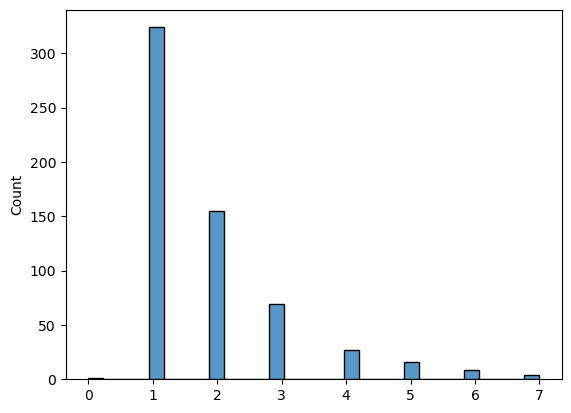

In [17]:
sns.histplot(X.sum(axis=0))

In [18]:
def fit_model(X, y):
    # Try out model with alpha = 1.0. This will get overwritten in the gridsearch
    model = mord.LogisticAT(alpha=0.1)
    #model = LogisticAT(alpha=1.0)

    model.fit(X, y)

    # The score is negative of mean absolute error between prediction and response vector
    print(f"Model Score with alpha={model.alpha} : {model.score(X, y):.2f}")
    return model

In [19]:
model_1 = fit_model(X, y)

Model Score with alpha=0.1 : -0.02


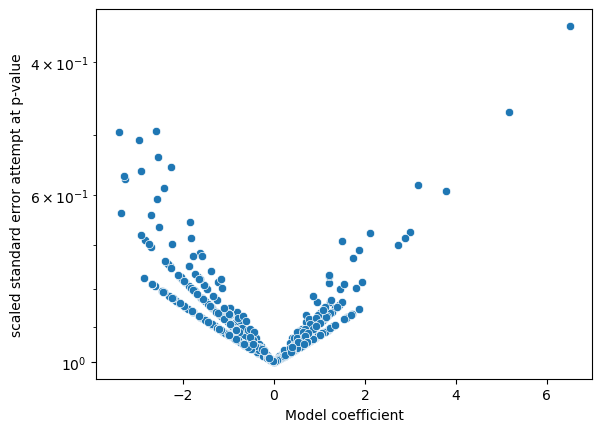

In [20]:
pval = (1 - scipy.stats.norm.cdf(np.abs(model_1.coef_ * np.sqrt(X.sum(axis=0)) / 10))) * 2
sns.scatterplot(x=model_1.coef_,y=pval )

ax = plt.gca()
ax.set_yscale('log')
ax.invert_yaxis()

plt.xlabel("Model coefficient")
plt.ylabel("scaled standard error attempt at p-value")
pass

In [21]:
def get_model_coefs_as_df(model, X, y, enc, parent):
    results = pd.DataFrame({'feature':enc.features, 'coef':model.coef_, 
                            'N_obs':X.sum(axis=0).astype(int)})
    results["adj_coef"] = results.coef * np.sqrt(results["N_obs"])
    #results["coef_rank"] = 1
    #results.loc[np.argsort(results.adj_coef.to_numpy()), "coef_rank"] = np.arange(1, len(results)+1)[::-1]
    results["coef_rank"] = rankdata(-results.adj_coef)

    results["parent"]  = parent
    # count the number of observations in each response category for a feature
    for category, response in response_map.items():
        results["N_obs_" + category] = \
                X[y == response, :].sum(axis=0).astype(int)


    return results.sort_values(['adj_coef'], ascending=False)    

In [22]:
results_1 = get_model_coefs_as_df(model_1, X, y, enc_1, parent)

In [23]:
parent = "2L"
X, y, enc_2 = create_design_response_matrices(final_seqs=final_seqs, parent = parent)
model_2 = fit_model(X, y)
results_2 = get_model_coefs_as_df(model_2, X, y, enc_2, parent)
results_2

Model Score with alpha=0.1 : -0.04


,feature,coef,N_obs,adj_coef,coef_rank,parent,N_obs_H,N_obs_P,N_obs_L,N_obs_N
293,Y131H,5.611084,3,9.718682,1.0,2L,2,0,1,0
286,H129R,3.843298,5,8.593875,2.0,2L,2,0,2,1
573,E249G,3.713751,5,8.304199,3.0,2L,1,0,3,1
381,N167S,2.785814,6,6.823824,4.0,2L,1,0,4,1
429,N189S,4.718934,2,6.673580,5.0,2L,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...
169,Q80L,-4.855394,2,-6.866564,616.0,2L,0,0,0,2
598,L262P,-3.018051,6,-7.392684,617.0,2L,0,0,2,4
604,H264R,-4.258622,4,-8.517245,618.0,2L,0,0,0,4
173,Q82R,-6.343794,3,-10.987774,619.0,2L,0,0,0,3


In [24]:
parent = "3VRL"
X, y, enc_3 = create_design_response_matrices(final_seqs=final_seqs, parent = parent)
model_3 = fit_model(X, y)
results_3 = get_model_coefs_as_df(model_3, X, y, enc_3, parent)
results_3

Model Score with alpha=0.1 : -0.09


,feature,coef,N_obs,adj_coef,coef_rank,parent,N_obs_H,N_obs_P,N_obs_L,N_obs_N
545,L261F,5.653804,2,7.995687,1.0,3VRL,2,0,0,0
98,D49V,4.599611,2,6.504832,2.0,3VRL,2,0,0,0
5,P6R,3.461340,3,5.995216,3.0,3VRL,1,0,1,1
94,R48C,4.157562,2,5.879680,4.0,3VRL,1,1,0,0
216,C101S,3.762540,2,5.321035,5.0,3VRL,0,2,0,0
...,...,...,...,...,...,...,...,...,...,...
180,G86S,-3.185015,3,-5.516608,558.0,3VRL,0,0,0,3
169,L81P,-2.795285,4,-5.590570,559.0,3VRL,0,0,2,2
436,M209V,-3.437631,3,-5.954152,560.0,3VRL,0,0,1,2
387,I184T,-3.215849,4,-6.431698,561.0,3VRL,0,0,1,3


### Combine all the results

In [25]:
all_results_pd = pd.concat([results_1, results_2, results_3])
all_results_pd = all_results_pd[all_results_pd.feature != "*0*"].copy() # remove wild type

all_results_pd["c_feature"] = all_results_pd.feature.str.slice(1, None)
all_results_pd

,feature,coef,N_obs,adj_coef,coef_rank,parent,N_obs_H,N_obs_P,N_obs_L,N_obs_N,c_feature
505,K227E,6.499321,2,9.191427,1.0,1VH,1,0,1,0,227E
179,G86D,5.156986,2,7.293080,2.0,1VH,1,0,1,0,86D
450,N198K,3.174595,3,5.498560,3.0,1VH,1,0,2,0,198K
119,S60G,3.788052,2,5.357114,4.0,1VH,1,0,1,0,60G
21,A15S,2.999445,2,4.241856,5.0,1VH,1,0,1,0,15S
...,...,...,...,...,...,...,...,...,...,...,...
180,G86S,-3.185015,3,-5.516608,558.0,3VRL,0,0,0,3,86S
169,L81P,-2.795285,4,-5.590570,559.0,3VRL,0,0,2,2,81P
436,M209V,-3.437631,3,-5.954152,560.0,3VRL,0,0,1,2,209V
387,I184T,-3.215849,4,-6.431698,561.0,3VRL,0,0,1,3,184T


In [26]:
all_results_pd["N_lib"] = all_results_pd.groupby("c_feature")["c_feature"].transform(lambda x: len(x))

In [27]:
all_results_pd["avg_rank"] = all_results_pd.groupby("c_feature")["coef_rank"].transform(lambda x: x.mean())

In [28]:
all_results_pd["worst_rank"] = all_results_pd.groupby("c_feature")["coef_rank"].transform(lambda x: x.max())

In [29]:
all_results_pd.sort_values("avg_rank")

,feature,coef,N_obs,adj_coef,coef_rank,parent,N_obs_H,N_obs_P,N_obs_L,N_obs_N,c_feature,N_lib,avg_rank,worst_rank
545,L261F,5.653804,2,7.995687,1.0,3VRL,2,0,0,0,261F,1,1.0,1.0
293,Y131H,5.611084,3,9.718682,1.0,2L,2,0,1,0,131H,1,1.0,1.0
119,S60G,3.788052,2,5.357114,4.0,1VH,1,0,1,0,60G,2,8.0,12.0
130,S60G,2.678856,3,4.639915,12.0,2L,0,1,2,0,60G,2,8.0,12.0
338,F152L,1.503878,7,3.978887,8.0,1VH,1,0,4,2,152L,1,8.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
588,F261L,-2.712714,3,-4.698558,594.0,1VH,0,0,0,3,261L,2,598.0,602.0
595,F261L,-2.882161,3,-4.992050,602.0,2L,0,0,0,3,261L,2,598.0,602.0
509,L222Q,-2.635002,3,-4.563958,598.0,2L,0,0,1,2,222Q,1,598.0,598.0
136,H67R,-1.840655,6,-4.508667,593.0,1VH,0,0,2,4,67R,2,601.0,609.0


In [30]:
# top 5 ranks
all_results_pd.sort_values("avg_rank").groupby("c_feature").head(1).head(5)

,feature,coef,N_obs,adj_coef,coef_rank,parent,N_obs_H,N_obs_P,N_obs_L,N_obs_N,c_feature,N_lib,avg_rank,worst_rank
545,L261F,5.653804,2,7.995687,1.0,3VRL,2,0,0,0,261F,1,1.0,1.0
293,Y131H,5.611084,3,9.718682,1.0,2L,2,0,1,0,131H,1,1.0,1.0
119,S60G,3.788052,2,5.357114,4.0,1VH,1,0,1,0,60G,2,8.0,12.0
338,F152L,1.503878,7,3.978887,8.0,1VH,1,0,4,2,152L,1,8.0,8.0
36,E19K,5.223568,1,5.223568,8.5,2L,1,0,0,0,19K,1,8.5,8.5


In [31]:
# top 5 ranks with mutations in all libraries
all_results_pd[all_results_pd.N_lib == 3].sort_values("avg_rank").groupby("c_feature").head(1).head(5)

,feature,coef,N_obs,adj_coef,coef_rank,parent,N_obs_H,N_obs_P,N_obs_L,N_obs_N,c_feature,N_lib,avg_rank,worst_rank
393,H172R,0.467874,6,1.146053,70.0,2L,0,2,2,2,172R,3,53.666667,70.0
564,E249G,0.662498,2,0.936914,103.0,1VH,0,0,2,0,249G,3,69.666667,103.0
193,K92R,1.453851,3,2.518143,18.0,1VH,0,0,2,1,92R,3,86.000000,192.0
516,I248V,1.486359,5,3.323601,38.0,3VRL,0,3,2,0,248V,3,87.666667,138.0
457,E201G,0.684626,3,1.185807,73.0,1VH,0,0,2,1,201G,3,89.500000,157.5


## Score 3-VRL high bin sequences

In [32]:
lib_3_high_seqs = final_seqs[(final_seqs.parent == "3VRL") & (final_seqs.category == "H")].ss_aa
lib_3_high_seqs

985        M21T,T77A,Q80R,D87G,V103A,T110S,Y131C,D158V
987                                         D49V,H210R
989                                         P44Q,E223D
992                                              R250S
994                                          R48C,S58R
995                                   S60C,E147D,E266V
997                                         G98C,V133A
998                                        M209K,C251R
999                                               S75G
1000                                        A16T,H172R
1001                                  D49V,T183A,R256C
1003                                 D105G,G192C,H210R
1005                                             R176H
1006                                             M229L
1008                              T14I,I42T,F62L,L152F
1010                                 R214C,A226D,E266K
1012                                              I23L
1013                                             L170M
1014      

In [33]:
# split on the comma
lib_3_high_seqs_split = lib_3_high_seqs.str.split(",", expand=True).reset_index()
# convert to a long list of mutations
# but we put the index in so we know which mutations belong to which sequences
lib_3_high_seqs_long = pd.melt(lib_3_high_seqs_split, id_vars=["index"], var_name="mutation_number").dropna()

# drop wild type amino acid so we can compare with the results from other models
lib_3_high_seqs_long["c_feature"] = lib_3_high_seqs_long.value.str.slice(1)

In [34]:
lib_3_score_3 = (pd.merge(lib_3_high_seqs_long, all_results_pd[all_results_pd.parent == "3VRL"])
                 .groupby("index")["coef"]
                 .sum())

In [35]:
lib_3_score_2 = (pd.merge(lib_3_high_seqs_long, all_results_pd[all_results_pd.parent == "2L"])
                 .groupby("index")["coef"]
                 .sum())
lib_3_score_1 = (pd.merge(lib_3_high_seqs_long, all_results_pd[all_results_pd.parent == "1VH"])
                 .groupby("index")["coef"]
                 .sum())

In [36]:
lib_3_high_seqs_scores = pd.DataFrame(lib_3_high_seqs)

In [37]:
lib_3_high_seqs_scores["model_3"] = 0.
lib_3_high_seqs_scores.loc[lib_3_score_3.index.to_numpy(), "model_3"] = lib_3_score_3.to_numpy()

lib_3_high_seqs_scores["model_2"] = 0.
lib_3_high_seqs_scores.loc[lib_3_score_2.index.to_numpy(), "model_2"] = lib_3_score_2.to_numpy()

lib_3_high_seqs_scores["model_1"] = 0.
lib_3_high_seqs_scores.loc[lib_3_score_1.index.to_numpy(), "model_1"] = lib_3_score_1.to_numpy()

lib_3_high_seqs_scores

,ss_aa,model_3,model_2,model_1
985,"M21T,T77A,Q80R,D87G,V103A,T110S,Y131C,D158V",6.193165,-0.454779,-2.648715
987,"D49V,H210R",4.671957,-1.957175,-0.006403
989,"P44Q,E223D",4.150944,0.073422,0.000000
992,R250S,2.045012,0.000000,0.736911
994,"R48C,S58R",5.839895,-0.483932,0.000000
995,"S60C,E147D,E266V",5.827058,-1.905062,0.881643
997,"G98C,V133A",4.648830,0.278257,0.212094
998,"M209K,C251R",3.539115,-1.373323,-1.984238
999,S75G,2.923553,-1.310668,0.548995
1000,"A16T,H172R",4.049425,0.467874,0.775358


In [38]:
# rank data (negative is used so that the highest value gets the lowest rank)
lib_3_high_seqs_scores["model_3_rank"] = rankdata(-lib_3_high_seqs_scores.model_3)
lib_3_high_seqs_scores["model_2_rank"] = rankdata(-lib_3_high_seqs_scores.model_2)
lib_3_high_seqs_scores["model_1_rank"] = rankdata(-lib_3_high_seqs_scores.model_1)



In [39]:
lib_3_high_seqs_scores["avg_rank"] = lib_3_high_seqs_scores[["model_3_rank", "model_2_rank", 
                                                             "model_1_rank"]].mean(axis=1)

In [40]:
lib_3_high_seqs_scores.sort_values("avg_rank")

,ss_aa,model_3,model_2,model_1,model_3_rank,model_2_rank,model_1_rank,avg_rank
1019,"D105V,V166A,G186A",5.481341,2.822939,0.711450,8.0,1.0,6.0,5.000000
1001,"D49V,T183A,R256C",7.093158,-0.462987,2.054347,1.0,19.0,1.0,7.000000
997,"G98C,V133A",4.648830,0.278257,0.212094,13.0,6.0,11.0,10.000000
1018,"R233Q,L261F",6.003508,0.000000,0.000000,3.0,12.0,15.5,10.166667
1000,"A16T,H172R",4.049425,0.467874,0.775358,23.0,4.0,4.0,10.333333
1031,"A122V,L261F",4.621974,0.052798,0.423000,14.0,8.5,10.0,10.833333
1024,"K64E,A69G",4.935719,1.237630,-0.958875,9.0,3.0,22.0,11.333333
995,"S60C,E147D,E266V",5.827058,-1.905062,0.881643,5.0,26.0,3.0,11.333333
1025,"V38I,V166I",4.808823,0.052798,0.000000,10.0,8.5,15.5,11.333333
1033,H28Q,4.505544,-0.012820,1.305213,17.5,15.0,2.0,11.500000


In [41]:
# write out to excel

model_results_excel_filename = f"../output/ordinal_Oct22_model_results.xlsx"


with pd.ExcelWriter(model_results_excel_filename, mode='w') as writer:

    all_results_pd.sort_values("avg_rank").to_excel(
        writer, index=False, sheet_name="feature_scores")
    
    lib_3_high_seqs_scores.sort_values("avg_rank").to_excel(
        writer, sheet_name='lib_3VRL_high_seq_scores', index=False)